# Optimal transport based dataset similarity

In [1]:
%env XLA_PYTHON_CLIENT_MEM_FRACTION=.99

env: XLA_PYTHON_CLIENT_MEM_FRACTION=.99


In [2]:
%load_ext autoreload

In [3]:
import gc
import pickle
import os
import warnings
from os.path import join, isfile

import scanpy as sc

In [4]:
%autoreload
from datasim.dataset_ot import DatasetMapping

## Load data

In [5]:
DATA_PATH = "/vol/data/dataset-similarity/preprocessed"
CACHE_DIR = "/vol/data/dataset-similarity/cache"
SAVE_DIR = "/vol/data/dataset-similarity/model-output/"
SAVE_VERSION = "_CoarseLabels_tau=1.00"
FIG_DIR = "/vol/data/dataset-similarity/figures"


QUERY_DATASET = "7d7cabfd-1d1f-40af-96b7-26a0825a306d"
REF_DATASET = "ced320a1-29f3-47c1-a735-513c7084d508"
N_TOP_GENES = 1500

INVALIDATE_CACHE = False

In [6]:
cache_file = join(
    CACHE_DIR, 
    "+".join([QUERY_DATASET, REF_DATASET, f"{N_TOP_GENES}HVGs"]) + ".pickle"
)
if os.path.isfile(cache_file):
    print("Using cached files...")
    with open(cache_file, "rb") as f:
        adata_query, adata_ref = pickle.load(f)
else:
    # load and preprocess data
    adata_query, adata_ref = DatasetMapping.preprocess_adatas(
        sc.read_h5ad(join(DATA_PATH, f"{QUERY_DATASET}.h5ad")),
        sc.read_h5ad(join(DATA_PATH, f"{REF_DATASET}.h5ad")),
        n_top_genes=N_TOP_GENES
    )
    with open(cache_file, "wb") as f:
        pickle.dump((adata_query, adata_ref), f)

adata_query.obs["cell_type_author"] = adata_query.obs["ct1"]
gc.collect();

Using cached files...


In [7]:
adata_query

AnnData object with n_obs × n_vars = 600929 × 1500
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'ct1', 'ct2', 'ct3', 'cell_type_author'
    var: 'feature_name'

In [8]:
adata_ref

AnnData object with n_obs × n_vars = 1058909 × 1500
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'author_cell_type', 'cell_type_author'
    var: 'feature_name'

## Initialize and fit optimal transport model

In [9]:
dataset_map = DatasetMapping(adata_query, adata_ref)

In [10]:
if not isfile(join(SAVE_DIR, f"ot-model-state{SAVE_VERSION}.pkl")) or INVALIDATE_CACHE:
    # ignore warnings here as scanpy.tl.rank_genes_groups throws a lot of warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dataset_map.init_geom(
            n_genes_de_gene_overlap=15,
            de_method="wilcoxon",
            p_value_threshold=0.01,
            batch_size=1024,
            epsilon=0.05
        )
    print(f"x size: {dataset_map.geom.x.shape[0] * dataset_map.geom.x.shape[1] * 4 / 1000**3} GB")
    print(f"y size: {dataset_map.geom.y.shape[0] * dataset_map.geom.y.shape[1] * 4 / 1000**3} GB")
    dataset_map.init_problem(tau_a=0.975, tau_b=0.975, marginals_distribution="balanced")
    dataset_map.solve()
    # save fitted OT model
    dataset_map.pickle_state(join(SAVE_DIR, f"ot-model-state{SAVE_VERSION}.pkl"))
else:
    print("Using cached OT model...")
    dataset_map.load_state(join(SAVE_DIR, f"ot-model-state{SAVE_VERSION}.pkl"))


Using cached OT model...


In [11]:
dataset_map.ot_solution.reg_ot_cost

Array(1.0736256, dtype=float32)

## Visualize optimal transport mapping

In [33]:
%autoreload
from datasim.plotting import plot_cluster_mapping, plot_cluster_distance, plot_sankey

### Cluster mapping

In [13]:
cluster_mapping = dataset_map.compute_cluster_mapping()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [16:41<00:00, 91.02s/it]


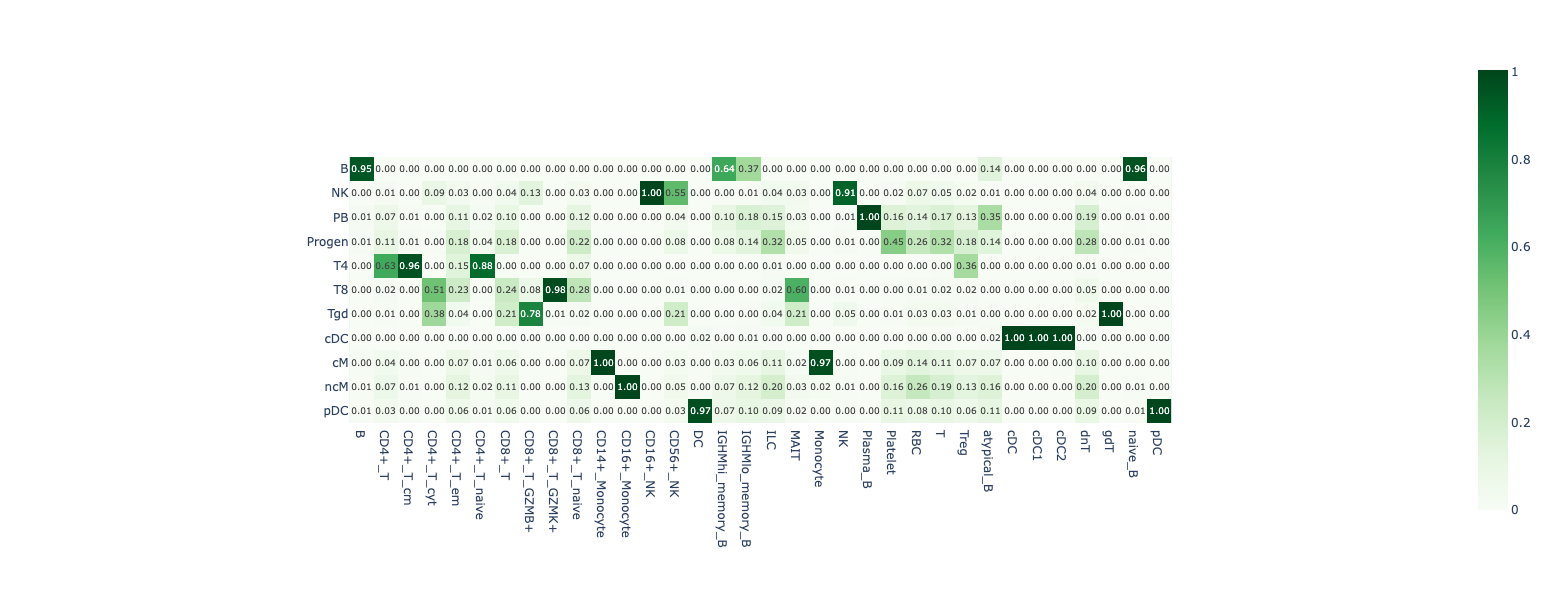

In [36]:
plot_cluster_mapping(cluster_mapping, height=600, show=True)

In [38]:
fig = plot_cluster_mapping(cluster_mapping, show=False)
fig.write_html(join(FIG_DIR, f"cluster-mapping{SAVE_VERSION}.html"))

### Cluster distances

In [16]:
cluster_distance = dataset_map.compute_cluster_distances(n_samples=25000)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 374/374 [03:51<00:00,  1.61it/s]


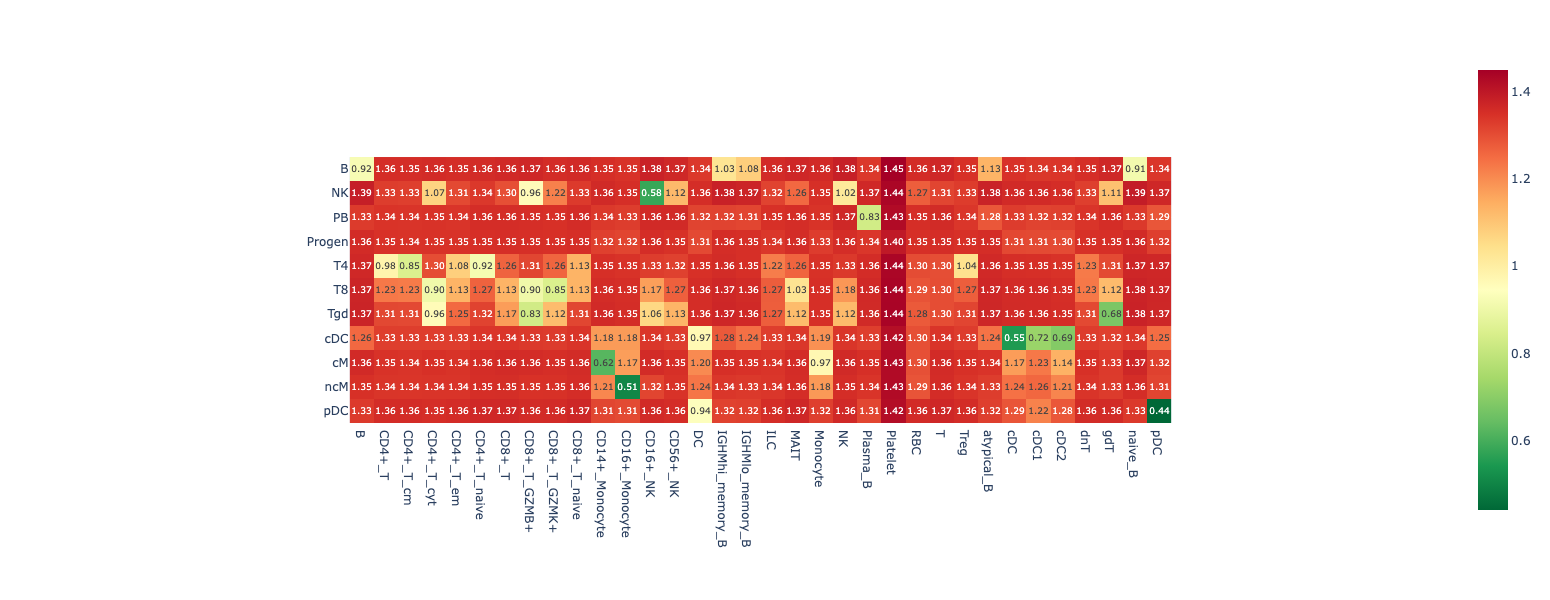

In [37]:
plot_cluster_distance(cluster_distance, height=600, show=True)

In [39]:
fig = plot_cluster_distance(cluster_distance, show=False)
fig.write_html(join(FIG_DIR, f"cluster-distance{SAVE_VERSION}.html"))

### Sankey visualization

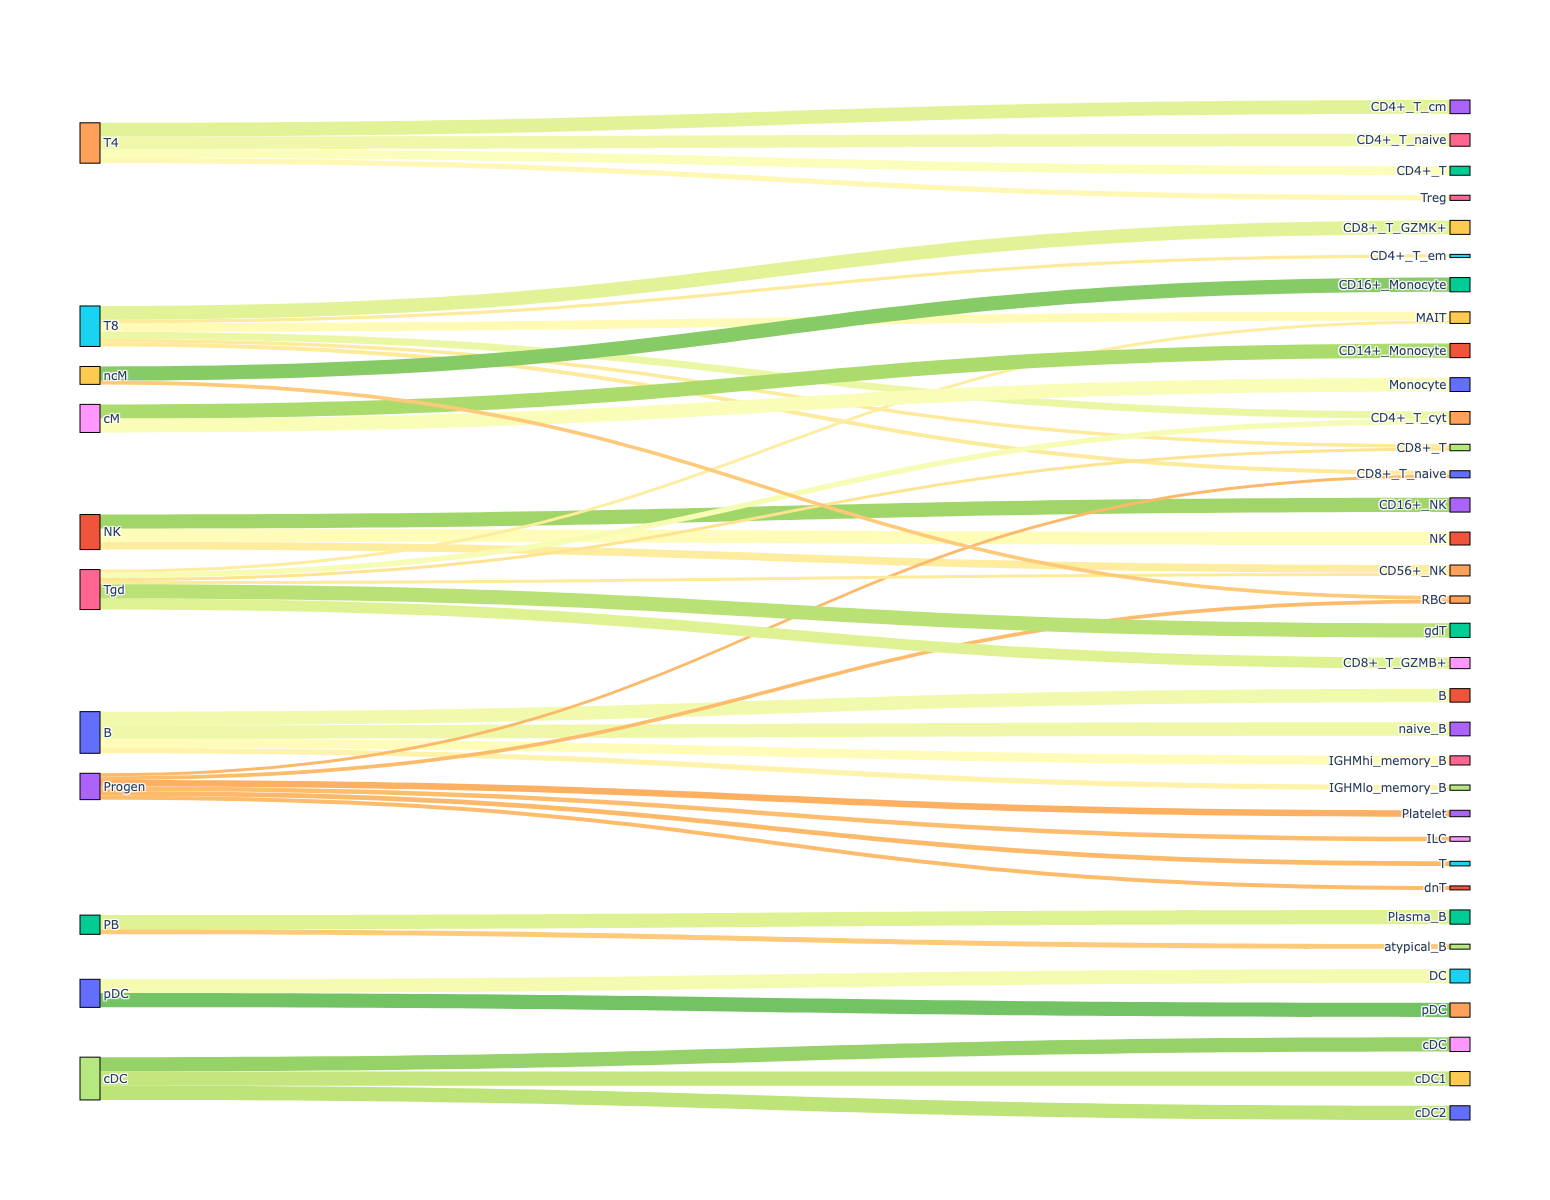

In [40]:
plot_sankey(cluster_mapping, cluster_distance, filter_threshold=0.2)

In [41]:
fig = plot_sankey(cluster_mapping, cluster_distance, show=False)
fig.write_html(join(FIG_DIR, f"sankey{SAVE_VERSION}.html"))

### Top n most similar clusters

In [46]:
top_n_labels = DatasetMapping.select_most_similar_clusters(
    cluster_mapping, 
    cluster_distance, 
    threshold_mass=0.1, 
    threshold_distance=1.2, 
    n_top=None
)
top_n_labels

{'B': ['naive_B', 'B', 'IGHMhi_memory_B', 'IGHMlo_memory_B', 'atypical_B'],
 'NK': ['CD16+_NK', 'NK', 'CD56+_NK', 'CD8+_T_GZMB+'],
 'PB': ['Plasma_B'],
 'Progen': [],
 'T4': ['CD4+_T_cm', 'CD4+_T_naive', 'CD4+_T', 'Treg', 'CD4+_T_em'],
 'T8': ['CD8+_T_GZMK+',
  'MAIT',
  'CD4+_T_cyt',
  'CD8+_T_naive',
  'CD8+_T',
  'CD4+_T_em'],
 'Tgd': ['gdT', 'CD8+_T_GZMB+', 'CD4+_T_cyt', 'CD56+_NK', 'CD8+_T', 'MAIT'],
 'cDC': ['cDC', 'cDC1', 'cDC2'],
 'cM': ['CD14+_Monocyte', 'Monocyte'],
 'ncM': ['CD16+_Monocyte'],
 'pDC': ['pDC', 'DC']}

## Save model output

In [47]:
cluster_mapping.to_parquet(join(SAVE_DIR, f"cluster_mapping{SAVE_VERSION}.parquet"))
cluster_distance.to_parquet(join(SAVE_DIR, f"cluster_distance{SAVE_VERSION}.parquet"))